# we will perform customer shopping behaviour -really imp for e-commerce

In [7]:
#importing imp libraires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#loading the data set
df = pd.read_csv('/content/customer_shopping_behavior.csv')

In [9]:
#how data looks like ?
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [10]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly
5049,1832,62,Male,Blouse,Clothing,71.0,Maine,M,Cyan,Summer,3.3,No,Free Shipping,No,5.0,Bank Transfer,Every 3 Months


In [11]:
df.sample(4)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
3021,3068,70,Female,Belt,Accessories,22.0,Missouri,S,Gray,Spring,3.5,No,Free Shipping,No,2.0,Cash,Weekly
2881,4735,56,Other,Phone,Accessories,NaN,Houston,M,Blue,Summer,4.0,Yes,Standard,No,31.0,Debit Card,Weekly
5020,1052,45,Male,Socks,Clothing,53.0,Ohio,M,Indigo,Fall,2.6,Yes,Free Shipping,Yes,39.0,PayPal,Annually
4438,1922,47,Male,Shirt,Clothing,36.0,Michigan,M,Green,Fall,3.5,No,Store Pickup,No,13.0,Venmo,Annually


In [12]:
df.shape  #before anything

(5050, 17)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [14]:
#what is the desperion of my numeric series
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [15]:
#how many null values whats the count
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),556
Location,0
Size,370
Color,0
Season,0


In [16]:
df = df.dropna(axis=0)

In [17]:
df.shape

(4009, 17)

In [18]:
#how many dublicates are their --before
df.duplicated().sum()

np.int64(48)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()#after removing --deacrease the chances of biasing

np.int64(0)

In [21]:
df.columns #before changing the columns name and removing extra character

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [22]:
df.columns = (df.columns.str.strip().str.lower().str.replace(' ','_' ,regex=False).str.replace("-", "_", regex=False).str.replace('(','',regex=False).str.replace(')','',regex=False))

In [23]:
df.columns #after cleaning --increased the readibility

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [24]:
#rounding up the rating to two digit
df['review_rating'] = df['review_rating'].round(2)

In [25]:
#fixing the data type -- deacreasing the memory consuption
df.info()#before

<class 'pandas.core.frame.DataFrame'>
Index: 3961 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3961 non-null   int64  
 1   age                     3961 non-null   int64  
 2   gender                  3961 non-null   object 
 3   item_purchased          3961 non-null   object 
 4   category                3961 non-null   object 
 5   purchase_amount_usd     3961 non-null   float64
 6   location                3961 non-null   object 
 7   size                    3961 non-null   object 
 8   color                   3961 non-null   object 
 9   season                  3961 non-null   object 
 10  review_rating           3961 non-null   float64
 11  subscription_status     3961 non-null   object 
 12  shipping_type           3961 non-null   object 
 13  discount_applied        3961 non-null   object 
 14  previous_purchases      3961 non-null   float

In [26]:
df['shipping_type'].value_counts()

,count
shipping_type,
Express,697
Standard,687
Free Shipping,667
Store Pickup,645
Next Day Air,645
2-Day Shipping,620


In [27]:
#changing the type from object to category
#those which have answer like yes no or have some category to distingush
selective_col = ['gender','discount_applied','subscription_status','category','shipping_type']

for col in selective_col:
  df[col] = df[col].astype('category')

In [28]:
#handling some miscelleneous data types
df['age'] = df['age'].astype('int8',errors='ignore')
df['previous_purchases'] = df['previous_purchases'].astype('int8',errors='ignore')
df['purchase_amount_usd'] = df['purchase_amount_usd'].astype('float16',errors='ignore')
df['review_rating'] = df['review_rating'].astype('float16',errors='ignore')


In [29]:
df.info()#after
#significant deacrease in memory size

<class 'pandas.core.frame.DataFrame'>
Index: 3961 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             3961 non-null   int64   
 1   age                     3961 non-null   int8    
 2   gender                  3961 non-null   category
 3   item_purchased          3961 non-null   object  
 4   category                3961 non-null   category
 5   purchase_amount_usd     3961 non-null   float16 
 6   location                3961 non-null   object  
 7   size                    3961 non-null   object  
 8   color                   3961 non-null   object  
 9   season                  3961 non-null   object  
 10  review_rating           3961 non-null   float16 
 11  subscription_status     3961 non-null   category
 12  shipping_type           3961 non-null   category
 13  discount_applied        3961 non-null   category
 14  previous_purchases      3961 

In [30]:
#lets perform visualiation and draws insights

In [31]:
df.sample()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
376,1463,38,Male,Sneakers,Footwear,90.0,Utah,S,Charcoal,Summer,4.800781,No,2-Day Shipping,Yes,2,Venmo,Quarterly


In [32]:
df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.199219,No,Standard,No,36,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.900391,Yes,Free Shipping,Yes,20,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.099609,No,2-Day Shipping,No,18,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.199219,No,Store Pickup,No,25,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.599609,No,Store Pickup,No,17,Credit Card,Weekly


Text(0.5, 1.0, 'Gender Distribution')

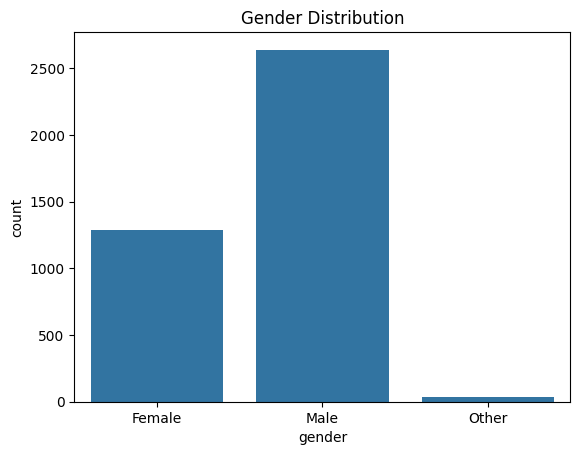

In [33]:
#what is the overall distribution of gender
sns.countplot(data=df , x='gender')
plt.title('Gender Distribution')

/tmp/ipykernel_3787/3021587915.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


Text(0.5, 1.0, ' Age Distribution Showing Customer Demographics Spread')

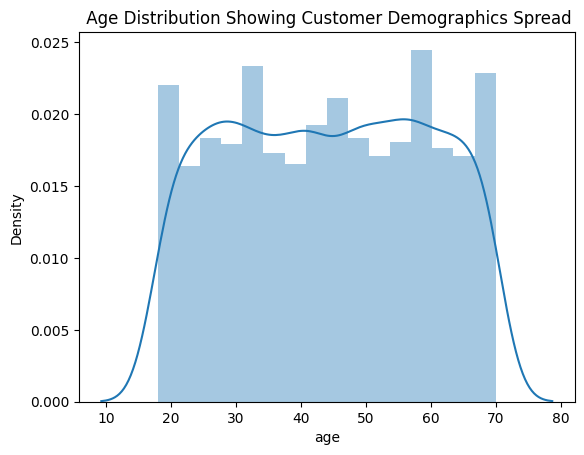

In [34]:
#what is the distribution if age
sns.distplot(df['age'])
plt.title(' Age Distribution Showing Customer Demographics Spread')

Text(0.5, 1.0, 'age variation across each group')

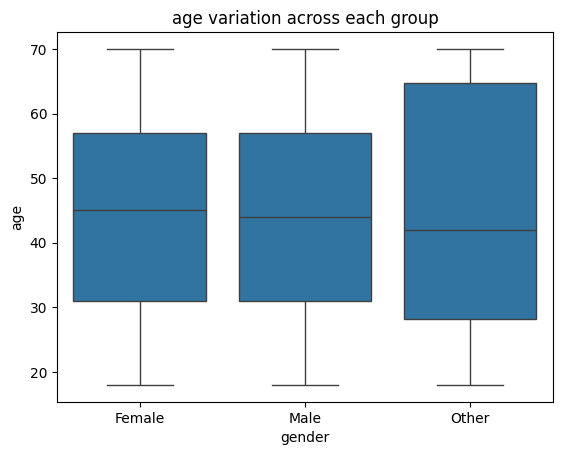

In [35]:
#what is the disribution of age in each gender
sns.boxplot(y='age',x='gender',data=df)
plt.title('age variation across each group')

/tmp/ipykernel_3787/3711584795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='item_purchased',order=df['item_purchased'].value_counts().head(10).index , palette='rocket')


Text(0.5, 1.0, 'top 10 most frequently purchased items')

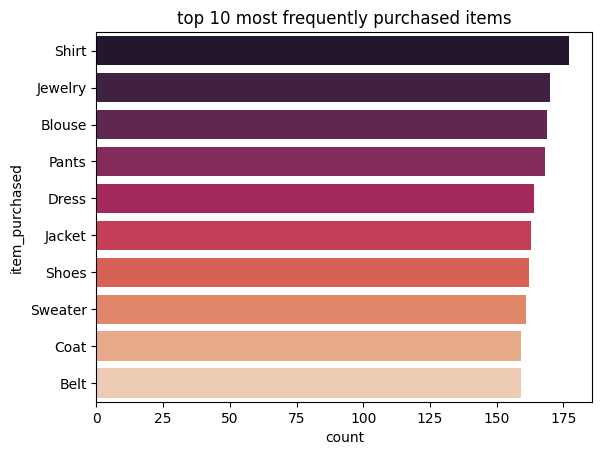

In [36]:
#what are the top 10 most purchased item
sns.countplot(data=df,y='item_purchased',order=df['item_purchased'].value_counts().head(10).index , palette='rocket')
plt.title('top 10 most frequently purchased items')

Text(0.5, 1.0, 'most used payment method')

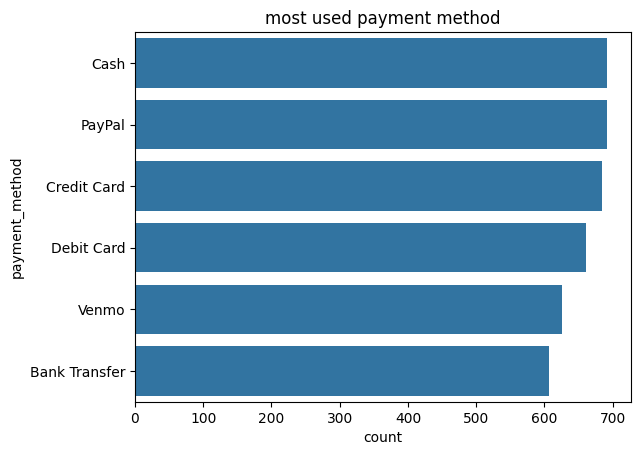

In [37]:
# which method most of the people comfortable with to pay their purchace
sns.countplot(data=df,y='payment_method',order=df['payment_method'].value_counts().index )
plt.title('most used payment method')

Text(0.5, 1.0, 'Distribution of subscription status by gender')

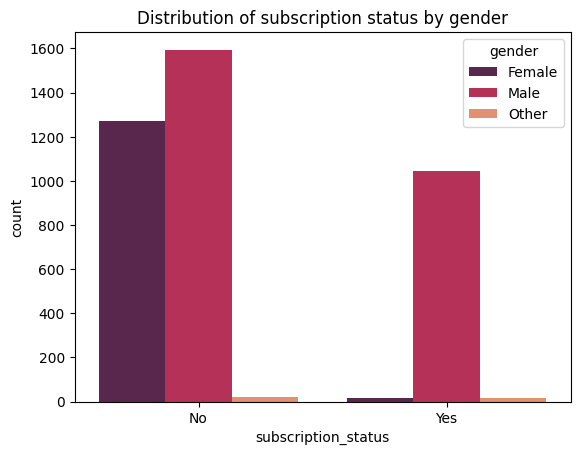

In [38]:
#what is the distribution subscription status by gender
sns.countplot(data=df,x='subscription_status',palette='rocket',hue='gender')
plt.title('Distribution of subscription status by gender')

Text(0.5, 1.0, 'season shoping trend')

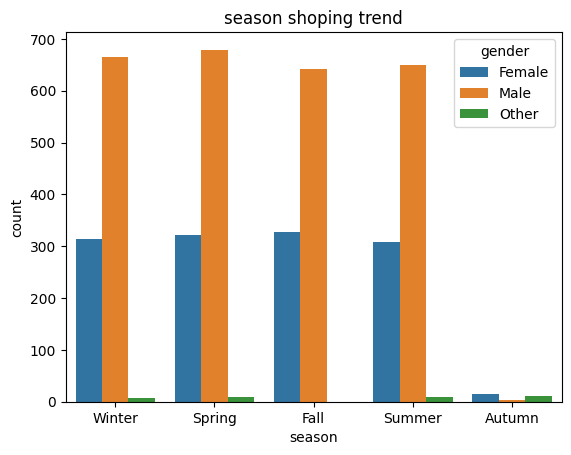

In [39]:
#how season is affecting customers
sns.countplot(data=df,x='season',hue='gender')
plt.title('season shoping trend')

Text(0.5, 1.0, 'variation of category by season')

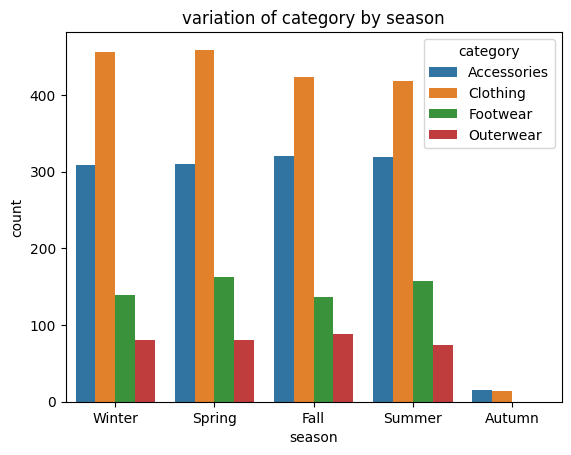

In [40]:
# what is the specific category demands with variation with season
sns.countplot(data=df,x='season',hue='category')
plt.title('variation of category by season')

/tmp/ipykernel_3787/3324605602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='location',order=df['location'].value_counts().nlargest(10).index , palette='rocket')


Text(0.5, 1.0, 'top 10 location from where customers are buying')

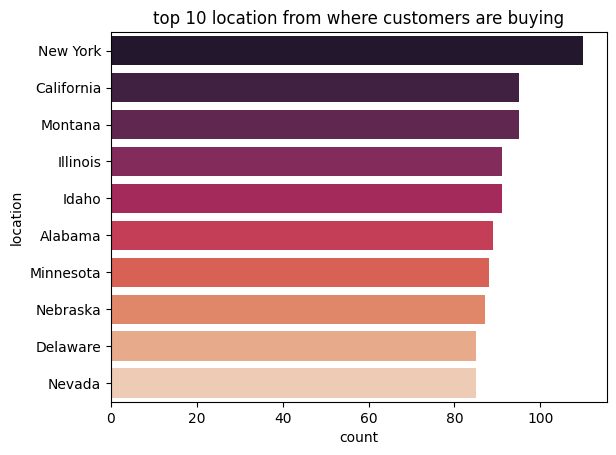

In [41]:
#what are the top 10 location from where cutomers are buying
sns.countplot(data=df,y='location',order=df['location'].value_counts().nlargest(10).index , palette='rocket')
plt.title('top 10 location from where customers are buying')

Text(0.5, 1.0, ' Relationship Between Discounts and Subscription Status')

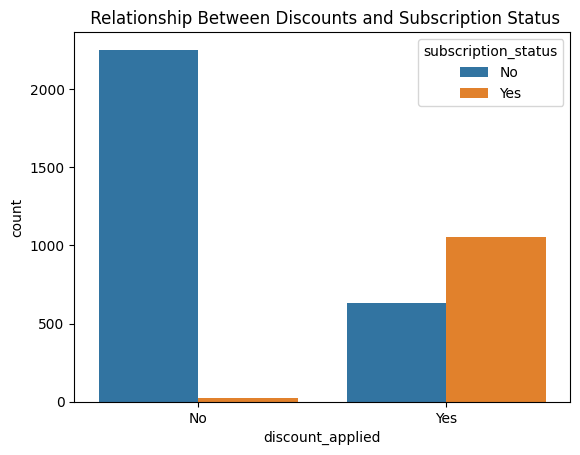

In [42]:
sns.countplot(x='discount_applied', hue='subscription_status', data=df)
plt.title(' Relationship Between Discounts and Subscription Status')

Text(0.5, 1.0, 'Frequency of Purchases')

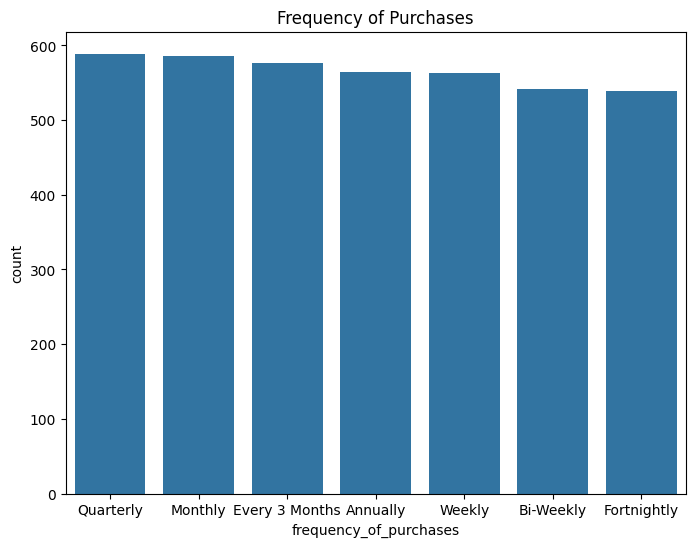

In [43]:
#what is the frequency of purchased items
plt.figure(figsize=(8,6))
sns.countplot(x='frequency_of_purchases', data=df, order=df['frequency_of_purchases'].value_counts().index)
plt.title('Frequency of Purchases')

Text(0.5, 1.0, 'Subscription Influence on Purchase Frequency')

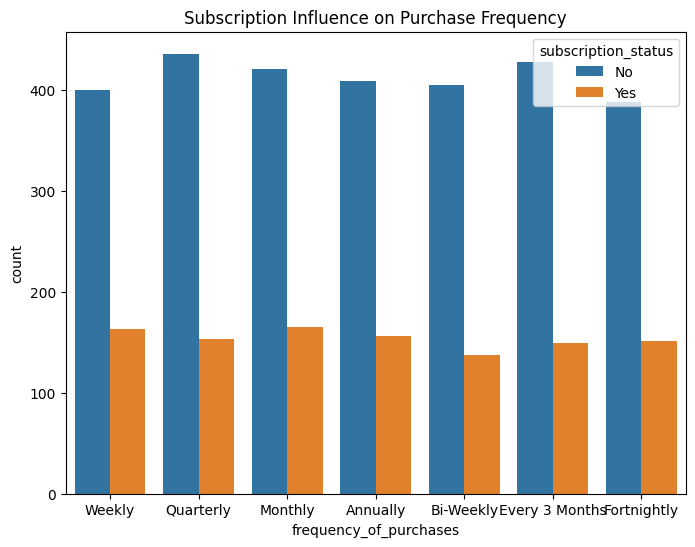

In [44]:
#how frequency of purchases affected by subscription
plt.figure(figsize=(8,6))
sns.countplot(x='frequency_of_purchases', hue='subscription_status', data=df)
plt.title('Subscription Influence on Purchase Frequency')


Text(0.5, 1.0, 'Category Preference by Gender Distribution')

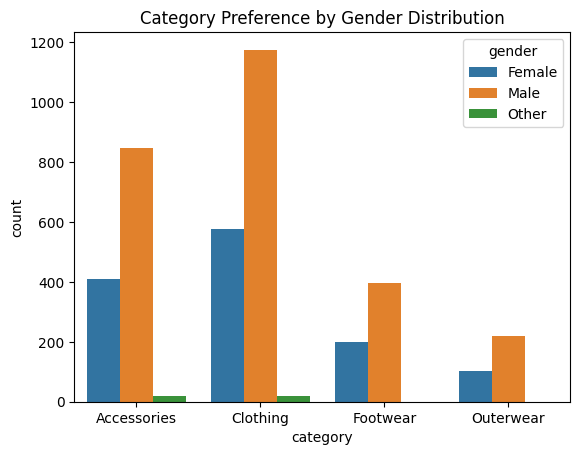

In [45]:
#what is the category prefrence by gender
sns.countplot(data=df, x='category', hue='gender')
plt.title('Category Preference by Gender Distribution')


In [46]:
#model training pre requisite
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [47]:
#copying the data so that no orignal changes happens
data = df.copy()

In [57]:
#encoding categorical variables
le = LabelEncoder()
# Select all non-numeric columns in 'data'
non_numeric_cols = data.select_dtypes(include=['object', 'category']).columns

for col in non_numeric_cols:
    data[col] = le.fit_transform(data[col])

In [58]:
#separating the data into dependent and independent cols
x = data.drop('subscription_status' ,axis=1)
y = data['subscription_status']

In [59]:
#separating the data into train and test
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [60]:
#feature selection
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

In [62]:
# Train the Logistic Regression model
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [65]:
# Make predictions on the test set
y_pred = model.predict(X_test)

Accuracy: 0.97


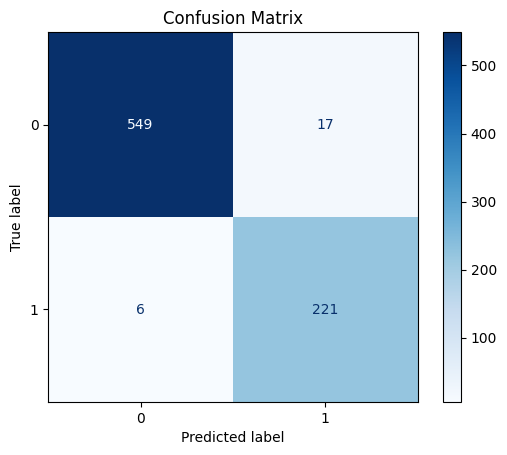

In [66]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()